# Evaluacion Parcial 2: Analisis Exploratorio de Datos
**Asignatura:** ADY1100 — Preprocesamiento de Datos  
**Caso:** Banco Financiero Global — Prediccion de Depositos a Plazo  

**Objetivo:** Identificar las caracteristicas que distinguen a los clientes que contratan un deposito a plazo, para optimizar futuras campanas de marketing.

## 0. Carga y Configuracion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
os.makedirs('graficos', exist_ok=True)

df = pd.read_csv('bank-additional-full.csv', sep=';')
df = df.drop_duplicates()

# Descartar 'duration' por ser data leaker
if 'duration' in df.columns:
    df = df.drop(columns=['duration'])

rename_columns = {
    'y':'deposito_plazo','age':'edad','job':'trabajo','marital':'estado_civil',
    'education':'educacion','default':'mora','housing':'vivienda','loan':'prestamo',
    'contact':'contacto','month':'mes','day_of_week':'dia_semana','campaign':'campana',
    'pdays':'dias_previos','previous':'anterior','poutcome':'resultado_anterior',
    'emp.var.rate':'var_empleo','cons.price.idx':'indice_precios',
    'cons.conf.idx':'indice_confianza','euribor3m':'tasa_euribor','nr.employed':'num_empleados'
}
df = df.rename(columns=rename_columns)
df['deposito_plazo'] = df['deposito_plazo'].map({'yes':'si','no':'no'})
df['deposito_plazo_num'] = df['deposito_plazo'].map({'si':1,'no':0})

df['trabajo'] = df['trabajo'].replace({
    'admin.':'administrativo','blue-collar':'obrero','entrepreneur':'empresario',
    'housemaid':'empleada_hogar','management':'gerencia','retired':'jubilado',
    'self-employed':'independiente','services':'servicios','student':'estudiante',
    'technician':'tecnico','unemployed':'desempleado','unknown':'desconocido'
})
df['estado_civil'] = df['estado_civil'].replace({
    'married':'casado','single':'soltero','divorced':'divorciado','unknown':'desconocido'})
df['educacion'] = df['educacion'].replace({
    'basic.4y':'basica_4','basic.6y':'basica_6','basic.9y':'basica_9',
    'high.school':'media','illiterate':'analfabeto',
    'professional.course':'tecnico_prof','university.degree':'universitario','unknown':'desconocido'
})
df['mora'] = df['mora'].replace({'yes':'si','no':'no','unknown':'desconocido'})
df['vivienda'] = df['vivienda'].replace({'yes':'si','no':'no','unknown':'desconocido'})
df['prestamo'] = df['prestamo'].replace({'yes':'si','no':'no','unknown':'desconocido'})
df['contacto'] = df['contacto'].replace({'cellular':'celular','telephone':'telefono_fijo'})
df['resultado_anterior'] = df['resultado_anterior'].replace({
    'failure':'fracaso','success':'exito','nonexistent':'sin_contacto'})

print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f"Variable objetivo: {df['deposito_plazo'].value_counts().to_dict()}")

Dataset cargado: 41,176 filas x 21 columnas
Variable objetivo: {'no': 36537, 'si': 4639}


In [2]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('deposito_plazo_num')
cat_cols = df.select_dtypes(include=['object']).columns.drop('deposito_plazo')

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1),(rcorr-1)))

num_corrs = [(col, np.abs(df[col].corr(df['deposito_plazo_num']))) for col in numeric_cols]
cat_corrs = [(col, cramers_v(df[col], df['deposito_plazo_num'])) for col in cat_cols]
all_corrs = sorted(num_corrs + cat_corrs, key=lambda x: x[1], reverse=True)

print('Top 10 Variables mas relevantes:')
for i,(col,corr) in enumerate(all_corrs[:10]):
    print(f'  {i+1}. {col}: {corr:.4f}')

Top 10 Variables mas relevantes:
  1. num_empleados: 0.3547
  2. dias_previos: 0.3249
  3. resultado_anterior: 0.3204
  4. tasa_euribor: 0.3077
  5. var_empleo: 0.2983
  6. mes: 0.2741
  7. anterior: 0.2302
  8. trabajo: 0.1520
  9. contacto: 0.1446
  10. indice_precios: 0.1361


## 1. Analisis Univariado

Exploracion de cada variable de forma individual. Se evalua distribucion, valores extremos y varianza.

**Variables del dataset:** edad, trabajo, estado_civil, educacion, mora, vivienda, prestamo, contacto, mes, dia_semana, campana, dias_previos, anterior, resultado_anterior, var_empleo, indice_precios, indice_confianza, tasa_euribor, num_empleados + variable objetivo.

### Grafico 1: Variable Objetivo — Desbalanceo de Clases

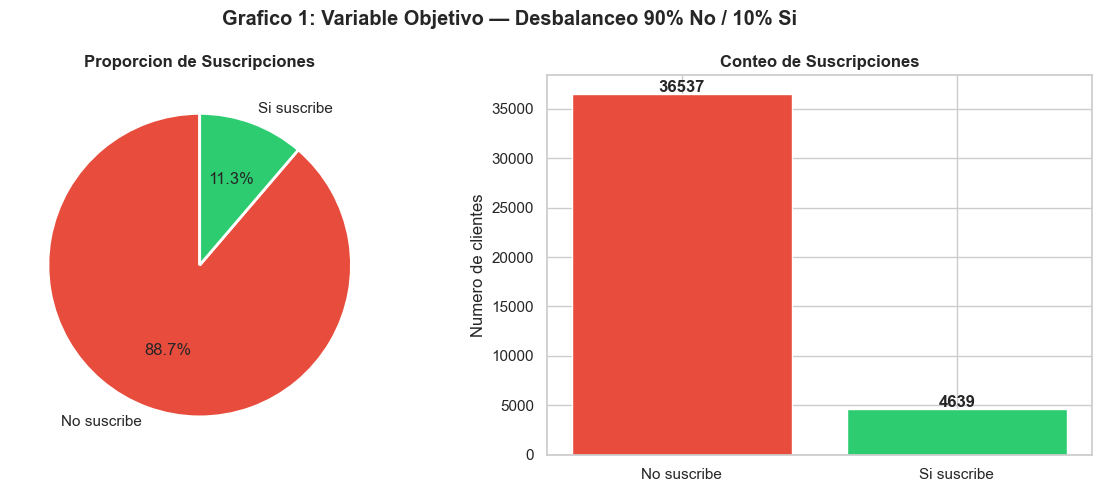

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
conteo = df['deposito_plazo'].value_counts()
colores = ['#e74c3c','#2ecc71']
axes[0].pie(conteo.values, labels=['No suscribe','Si suscribe'],
            autopct='%1.1f%%', colors=colores, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Proporcion de Suscripciones', fontweight='bold')
axes[1].bar(['No suscribe','Si suscribe'], conteo.values, color=colores, edgecolor='white')
for i, val in enumerate(conteo.values):
    axes[1].text(i, val+200, str(val), ha='center', fontweight='bold')
axes[1].set_ylabel('Numero de clientes')
axes[1].set_title('Conteo de Suscripciones', fontweight='bold')
plt.suptitle('Grafico 1: Variable Objetivo — Desbalanceo 90% No / 10% Si', fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/univariado_variable_objetivo.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 2: Edad — Distribucion Univariada

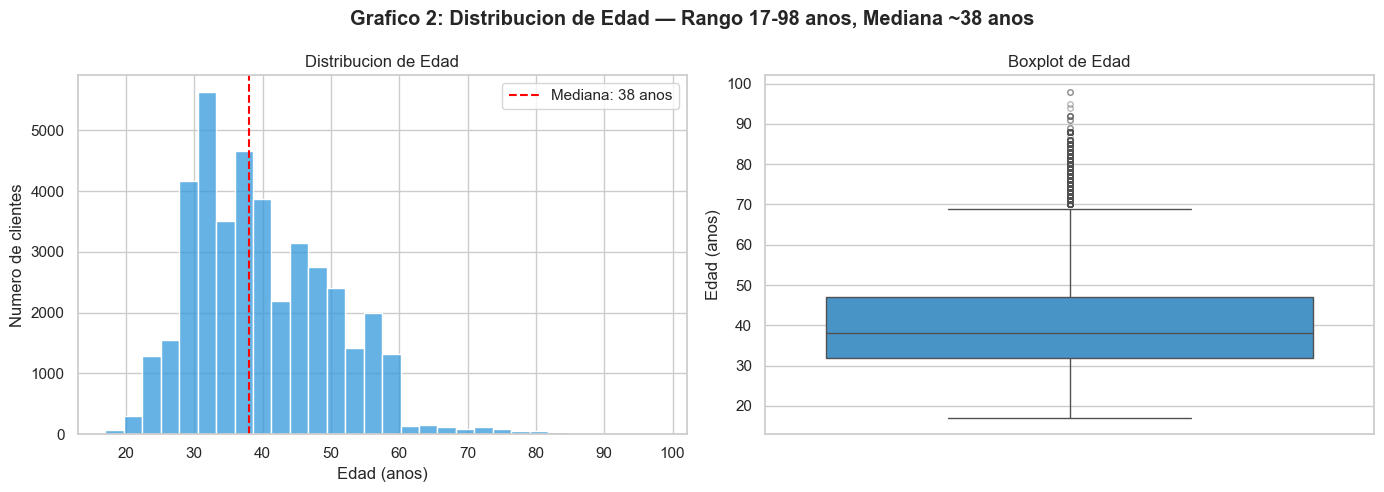

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='edad', bins=30, color='#3498db', ax=axes[0], edgecolor='white')
axes[0].set_xlabel('Edad (anos)')
axes[0].set_ylabel('Numero de clientes')
axes[0].set_title('Distribucion de Edad')
axes[0].axvline(df['edad'].median(), color='red', linestyle='--',
                label=f"Mediana: {df['edad'].median():.0f} anos")
axes[0].legend()
sns.boxplot(y=df['edad'], ax=axes[1], color='#3498db',
            flierprops=dict(marker='o', markersize=4, alpha=0.4))
axes[1].set_ylabel('Edad (anos)')
axes[1].set_title('Boxplot de Edad')
plt.suptitle('Grafico 2: Distribucion de Edad — Rango 17-98 anos, Mediana ~38 anos', fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/univariado_edad.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 3: Tipo de Trabajo — Distribucion

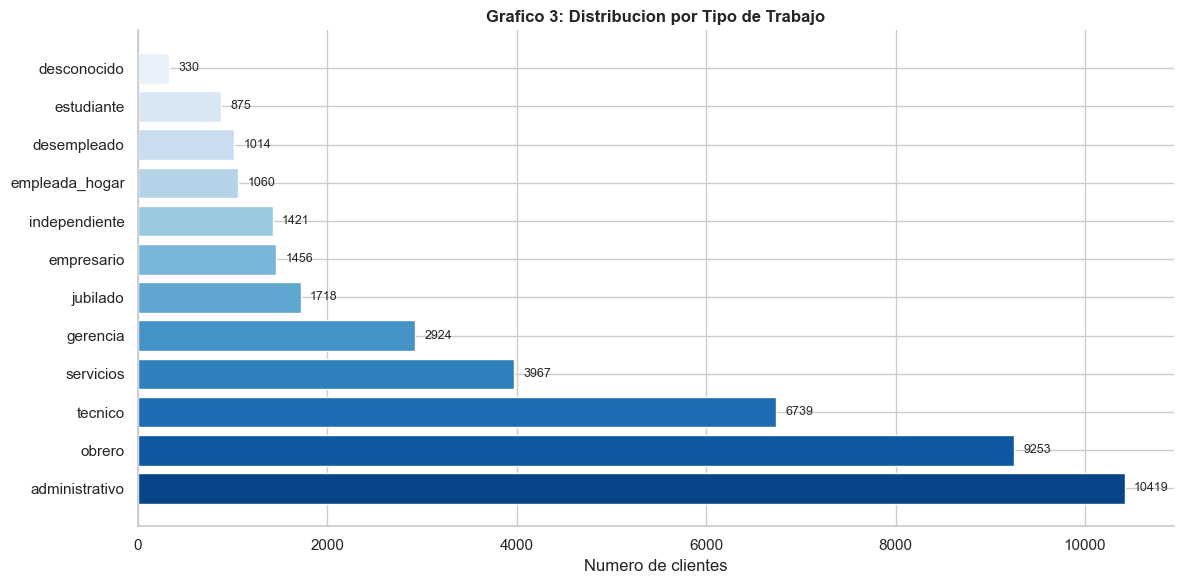

In [5]:
conteo_trabajo = df['trabajo'].value_counts()
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(conteo_trabajo.index, conteo_trabajo.values,
               color=sns.color_palette('Blues_r', len(conteo_trabajo)), edgecolor='white')
for bar, val in zip(bars, conteo_trabajo.values):
    ax.text(bar.get_width()+100, bar.get_y()+bar.get_height()/2,
            str(val), va='center', fontsize=9)
ax.set_xlabel('Numero de clientes')
ax.set_title('Grafico 3: Distribucion por Tipo de Trabajo', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('graficos/univariado_trabajo.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 4: Estado Civil — Distribucion

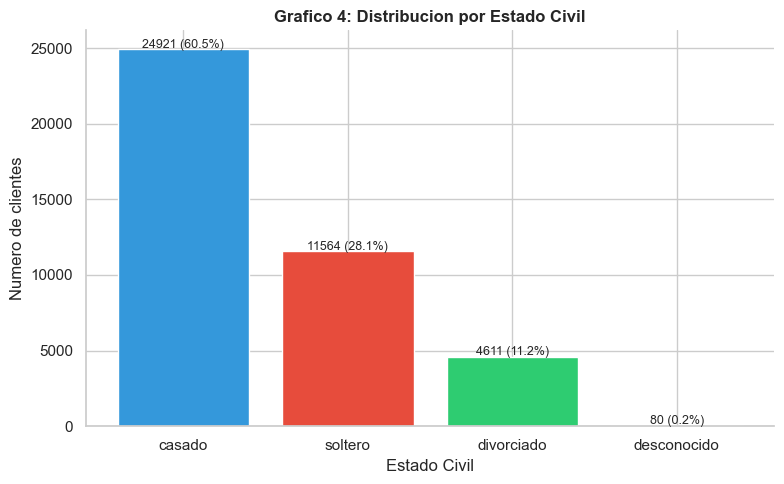

In [6]:
ec = df['estado_civil'].value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(ec.index, ec.values, color=['#3498db','#e74c3c','#2ecc71','#95a5a6'], edgecolor='white')
for i, (lbl, val) in enumerate(zip(ec.index, ec.values)):
    pct = val/len(df)*100
    ax.text(i, val+100, str(val)+' ('+str(round(pct,1))+'%)', ha='center', fontsize=9)
ax.set_xlabel('Estado Civil')
ax.set_ylabel('Numero de clientes')
ax.set_title('Grafico 4: Distribucion por Estado Civil', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('graficos/univariado_estado_civil.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 5: Nivel de Educacion — Distribucion

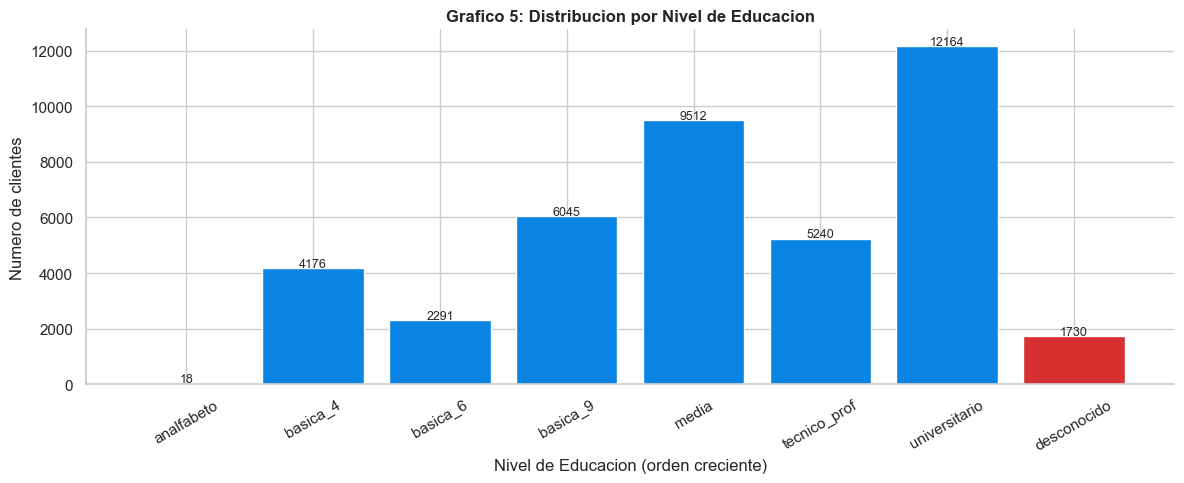

In [7]:
orden_edu = ['analfabeto','basica_4','basica_6','basica_9','media','tecnico_prof','universitario','desconocido']
edu_counts = df['educacion'].value_counts().reindex(orden_edu).dropna()
fig, ax = plt.subplots(figsize=(12, 5))
colores_edu = ['#d63031' if x=='desconocido' else '#0984e3' for x in edu_counts.index]
bars = ax.bar(edu_counts.index, edu_counts.values, color=colores_edu, edgecolor='white')
for bar, val in zip(bars, edu_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            str(val), ha='center', fontsize=9)
ax.set_xlabel('Nivel de Educacion (orden creciente)')
ax.set_ylabel('Numero de clientes')
ax.set_title('Grafico 5: Distribucion por Nivel de Educacion', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
sns.despine()
plt.tight_layout()
plt.savefig('graficos/univariado_educacion.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 6: Numero de Contactos en Campana — Valores Extremos

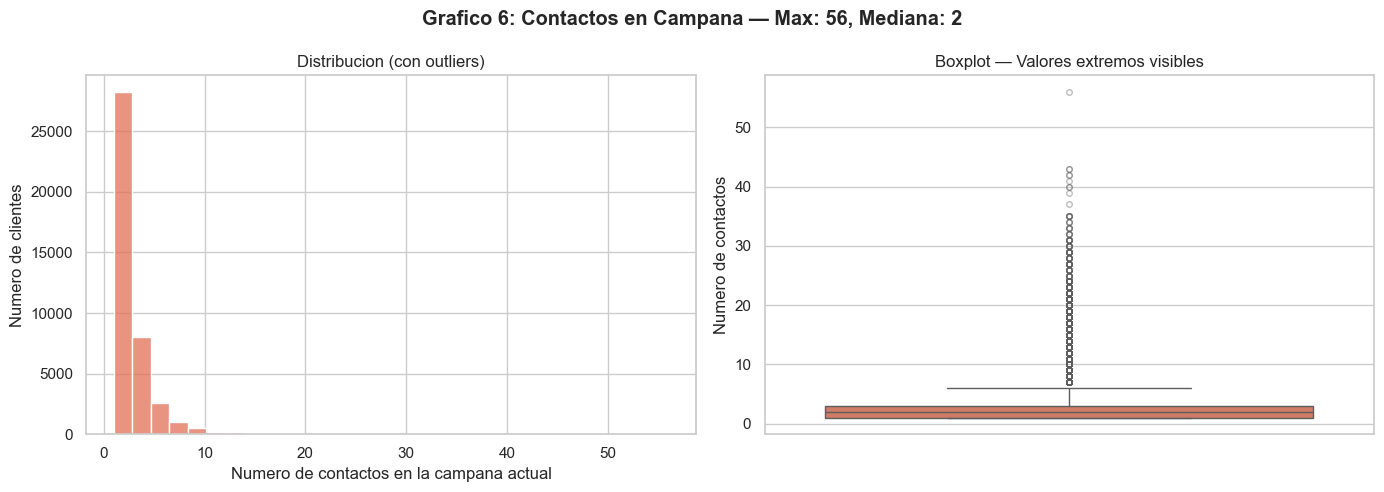

Percentil 95: 7 contactos | Valores > 10: 869 (2.1%)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='campana', bins=30, color='#e17055', ax=axes[0], edgecolor='white')
axes[0].set_xlabel('Numero de contactos en la campana actual')
axes[0].set_ylabel('Numero de clientes')
axes[0].set_title('Distribucion (con outliers)')
sns.boxplot(y=df['campana'], ax=axes[1], color='#e17055',
            flierprops=dict(marker='o', markersize=4, alpha=0.4))
axes[1].set_ylabel('Numero de contactos')
axes[1].set_title('Boxplot — Valores extremos visibles')
max_c = df['campana'].max()
med_c = int(df['campana'].median())
plt.suptitle('Grafico 6: Contactos en Campana — Max: '+str(max_c)+', Mediana: '+str(med_c), fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/univariado_campana_contactos.png', bbox_inches='tight', dpi=150)
plt.show()
p95 = df['campana'].quantile(0.95)
n_extremos = (df['campana']>10).sum()
print(f'Percentil 95: {p95:.0f} contactos | Valores > 10: {n_extremos} ({n_extremos/len(df)*100:.1f}%)')

### Grafico 7: Tasa Euribor 3 Meses — Variable Macroeconomica

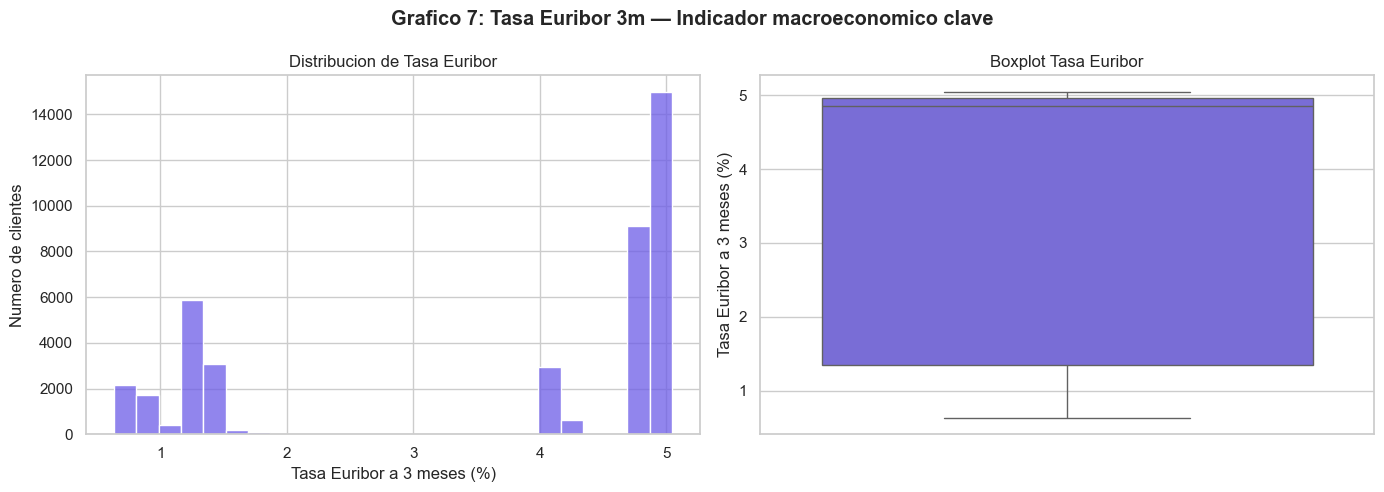

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='tasa_euribor', bins=25, color='#6c5ce7', ax=axes[0], edgecolor='white')
axes[0].set_xlabel('Tasa Euribor a 3 meses (%)')
axes[0].set_ylabel('Numero de clientes')
axes[0].set_title('Distribucion de Tasa Euribor')
sns.boxplot(y=df['tasa_euribor'], ax=axes[1], color='#6c5ce7',
            flierprops=dict(marker='o', markersize=4, alpha=0.4))
axes[1].set_ylabel('Tasa Euribor a 3 meses (%)')
axes[1].set_title('Boxplot Tasa Euribor')
plt.suptitle('Grafico 7: Tasa Euribor 3m — Indicador macroeconomico clave', fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/univariado_tasa_euribor.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 8: Variables Macroeconomicas — Panel Completo

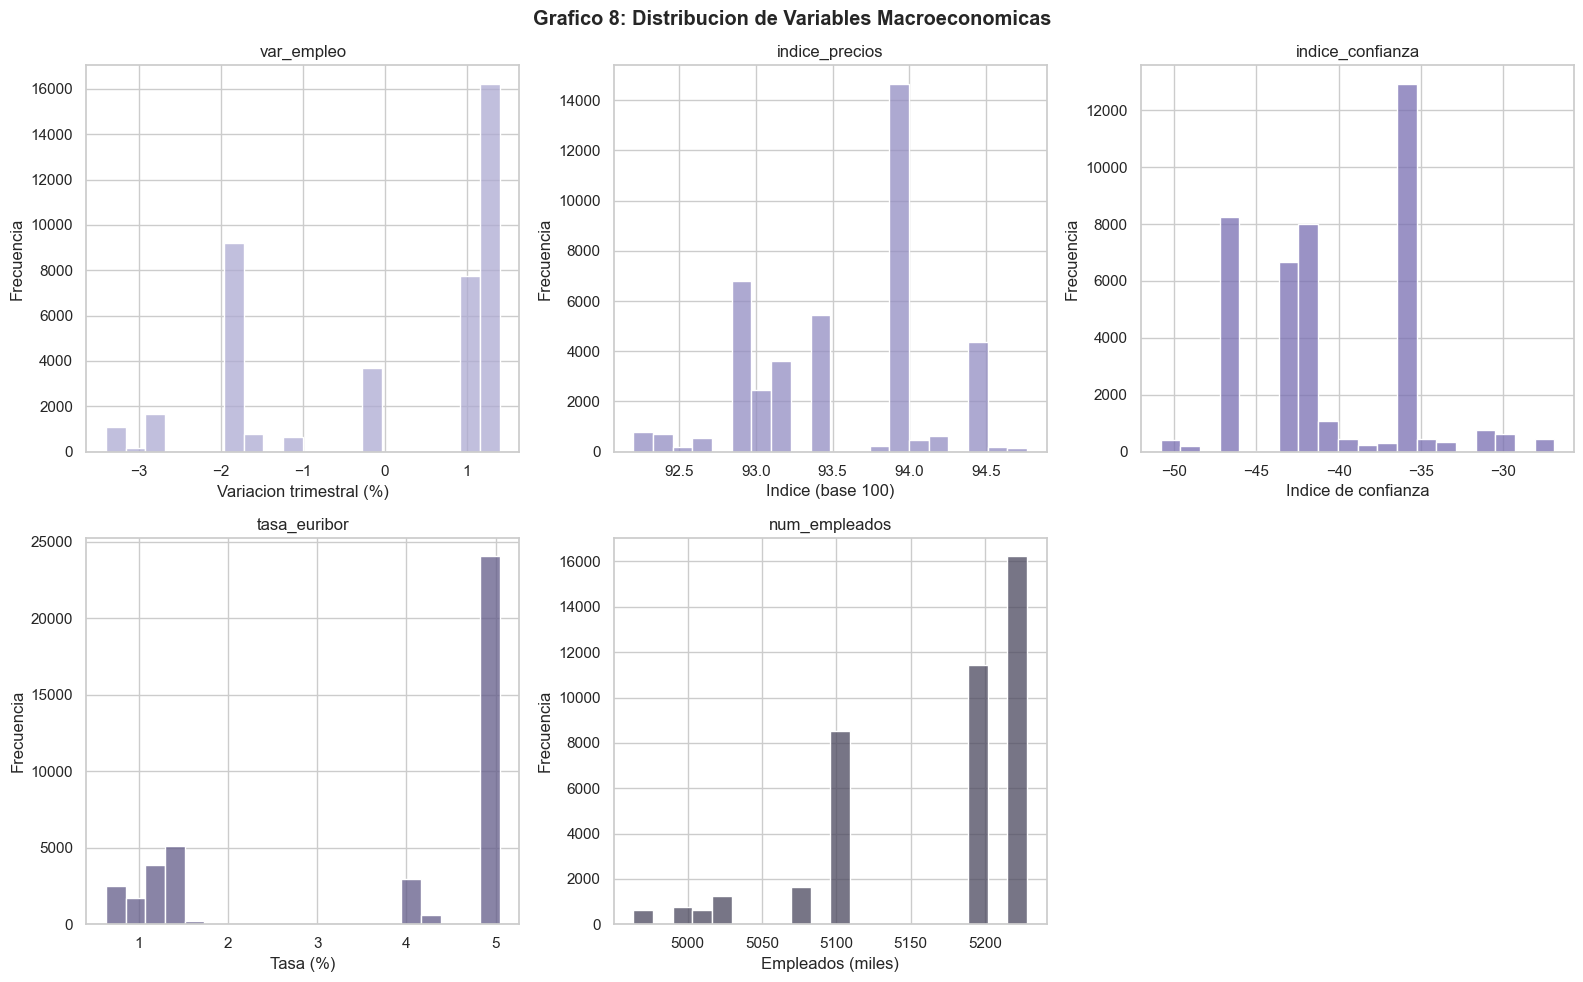

In [10]:
macro_cols = ['var_empleo','indice_precios','indice_confianza','tasa_euribor','num_empleados']
unidades = ['Variacion trimestral (%)','Indice (base 100)','Indice de confianza','Tasa (%)','Empleados (miles)']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, (col, unidad) in enumerate(zip(macro_cols, unidades)):
    sns.histplot(data=df, x=col, bins=20, color=sns.color_palette('Purples_d',5)[i],
                 ax=axes[i], edgecolor='white')
    axes[i].set_xlabel(unidad)
    axes[i].set_ylabel('Frecuencia')
    axes[i].set_title(col)
axes[5].axis('off')
plt.suptitle('Grafico 8: Distribucion de Variables Macroeconomicas', fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/univariado_variables_macroeconomicas.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 9: Mes de Contacto — Volumen de Llamadas

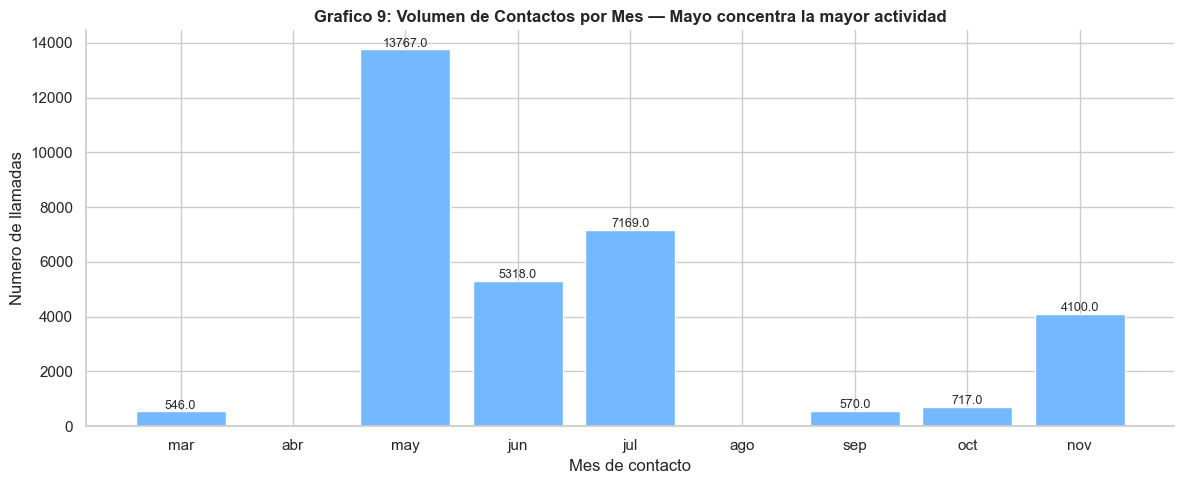

In [11]:
order_months = ['mar','abr','may','jun','jul','ago','sep','oct','nov','dic']
conteo_mes = df['mes'].value_counts().reindex(order_months)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(conteo_mes.index, conteo_mes.values, color='#74b9ff', edgecolor='white')
for i, val in enumerate(conteo_mes.values):
    ax.text(i, val+100, str(val), ha='center', fontsize=9)
ax.set_xlabel('Mes de contacto')
ax.set_ylabel('Numero de llamadas')
ax.set_title('Grafico 9: Volumen de Contactos por Mes — Mayo concentra la mayor actividad', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('graficos/univariado_mes_volumen.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 10: Resultado de Campana Anterior

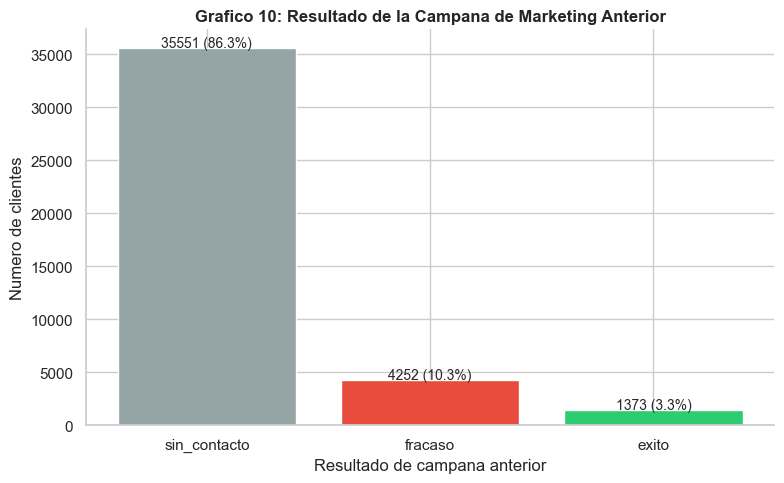

In [12]:
ra = df['resultado_anterior'].value_counts()
colores_ra = {'sin_contacto':'#95a5a6','fracaso':'#e74c3c','exito':'#2ecc71'}
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(ra.index, ra.values,
              color=[colores_ra.get(x,'#3498db') for x in ra.index], edgecolor='white')
for bar, val in zip(bars, ra.values):
    pct = val/len(df)*100
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
            str(val)+' ('+str(round(pct,1))+'%)', ha='center', fontsize=10)
ax.set_xlabel('Resultado de campana anterior')
ax.set_ylabel('Numero de clientes')
ax.set_title('Grafico 10: Resultado de la Campana de Marketing Anterior', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('graficos/univariado_resultado_anterior.png', bbox_inches='tight', dpi=150)
plt.show()

## 2. Analisis Bivariado

Relacion de cada variable con la variable objetivo `deposito_plazo`. Se usa **tasa de conversion** (frecuencia relativa) para comparaciones justas dado el desbalanceo 90/10%.

### Grafico 11: Correlacion de Todas las Variables con la Variable Objetivo

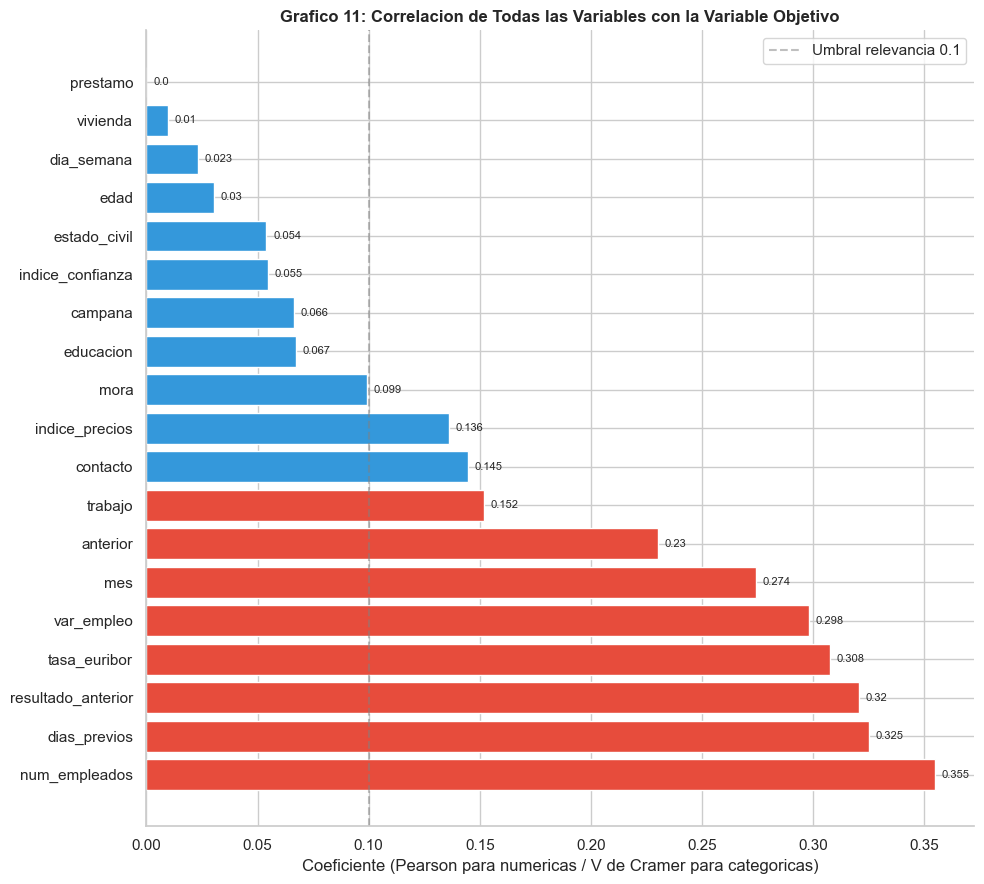

In [13]:
corrs_df = pd.DataFrame(all_corrs, columns=['Variable','Correlacion'])
fig, ax = plt.subplots(figsize=(10, 9))
colores_corr = ['#e74c3c' if v>0.15 else '#3498db' for v in corrs_df['Correlacion']]
bars = ax.barh(corrs_df['Variable'], corrs_df['Correlacion'], color=colores_corr, edgecolor='white')
for bar, val in zip(bars, corrs_df['Correlacion']):
    ax.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
            str(round(val,3)), va='center', fontsize=8)
ax.axvline(0.1, color='gray', linestyle='--', alpha=0.5, label='Umbral relevancia 0.1')
ax.set_xlabel('Coeficiente (Pearson para numericas / V de Cramer para categoricas)')
ax.set_title('Grafico 11: Correlacion de Todas las Variables con la Variable Objetivo', fontweight='bold')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('graficos/bivariado_correlacion_todas_variables.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 12: Edad vs Tasa de Conversion — Jubilados destacan

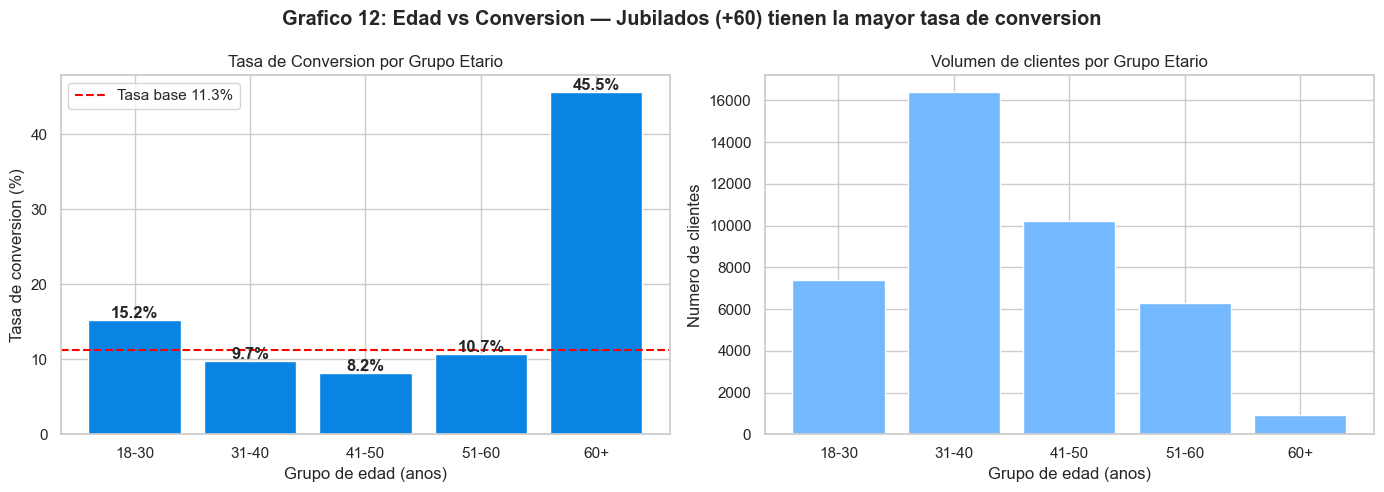

In [14]:
bins_edad = [17,30,40,50,60,100]
labels_edad = ['18-30','31-40','41-50','51-60','60+']
df['grupo_edad'] = pd.cut(df['edad'], bins=bins_edad, labels=labels_edad, right=True)
conv_edad = df.groupby('grupo_edad', observed=True)['deposito_plazo_num'].mean()*100
conteo_edad = df.groupby('grupo_edad', observed=True)['deposito_plazo_num'].count()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(conv_edad.index.astype(str), conv_edad.values, color='#0984e3', edgecolor='white')
for i, val in enumerate(conv_edad.values):
    axes[0].text(i, val+0.3, str(round(val,1))+'%', ha='center', fontweight='bold')
tasa_base = df['deposito_plazo_num'].mean()*100
axes[0].axhline(tasa_base, color='red', linestyle='--', label='Tasa base '+str(round(tasa_base,1))+'%')
axes[0].set_xlabel('Grupo de edad (anos)')
axes[0].set_ylabel('Tasa de conversion (%)')
axes[0].set_title('Tasa de Conversion por Grupo Etario')
axes[0].legend()
axes[1].bar(conteo_edad.index.astype(str), conteo_edad.values, color='#74b9ff', edgecolor='white')
axes[1].set_xlabel('Grupo de edad (anos)')
axes[1].set_ylabel('Numero de clientes')
axes[1].set_title('Volumen de clientes por Grupo Etario')
plt.suptitle('Grafico 12: Edad vs Conversion — Jubilados (+60) tienen la mayor tasa de conversion', fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/bivariado_edad_conversion.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 13: Tipo de Trabajo vs Tasa de Conversion

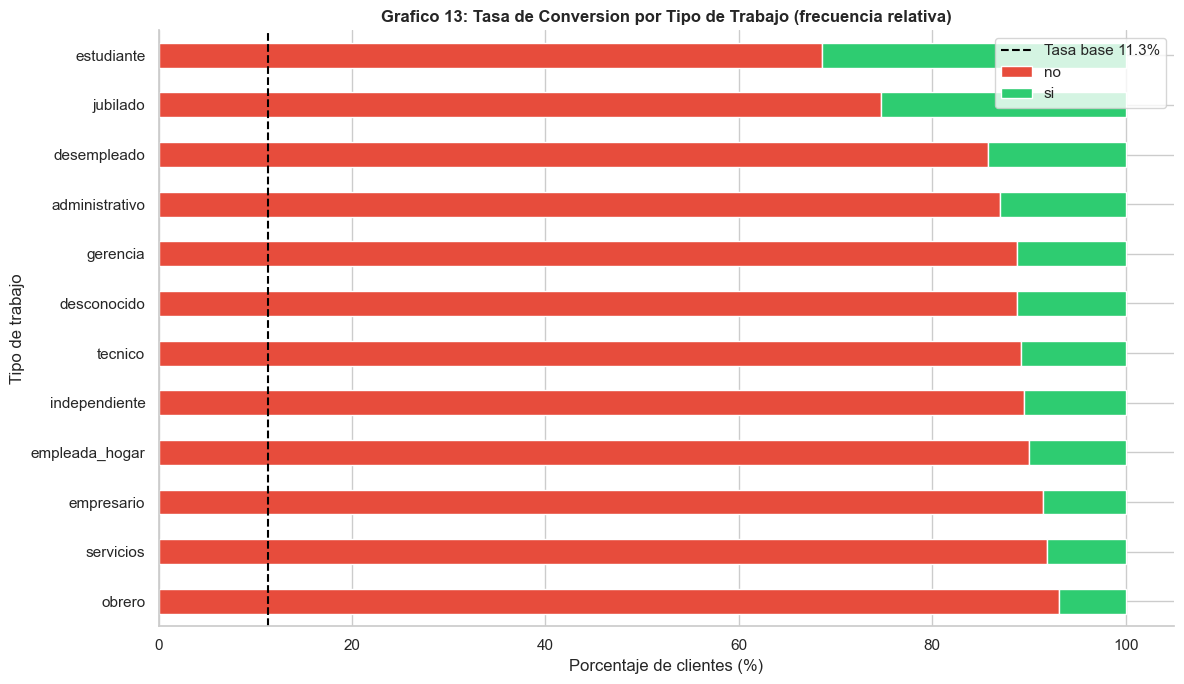

In [15]:
job_res = pd.crosstab(df['trabajo'], df['deposito_plazo'], normalize='index')*100
job_res = job_res.sort_values('si')
fig, ax = plt.subplots(figsize=(12, 7))
job_res.plot(kind='barh', stacked=True, color=['#e74c3c','#2ecc71'], ax=ax, edgecolor='white')
tasa_base = df['deposito_plazo_num'].mean()*100
ax.axvline(tasa_base, color='black', linestyle='--', linewidth=1.5,
           label='Tasa base '+str(round(tasa_base,1))+'%')
ax.set_xlabel('Porcentaje de clientes (%)')
ax.set_ylabel('Tipo de trabajo')
ax.set_title('Grafico 13: Tasa de Conversion por Tipo de Trabajo (frecuencia relativa)', fontweight='bold')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('graficos/bivariado_trabajo_conversion.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 14: Educacion vs Tasa de Conversion

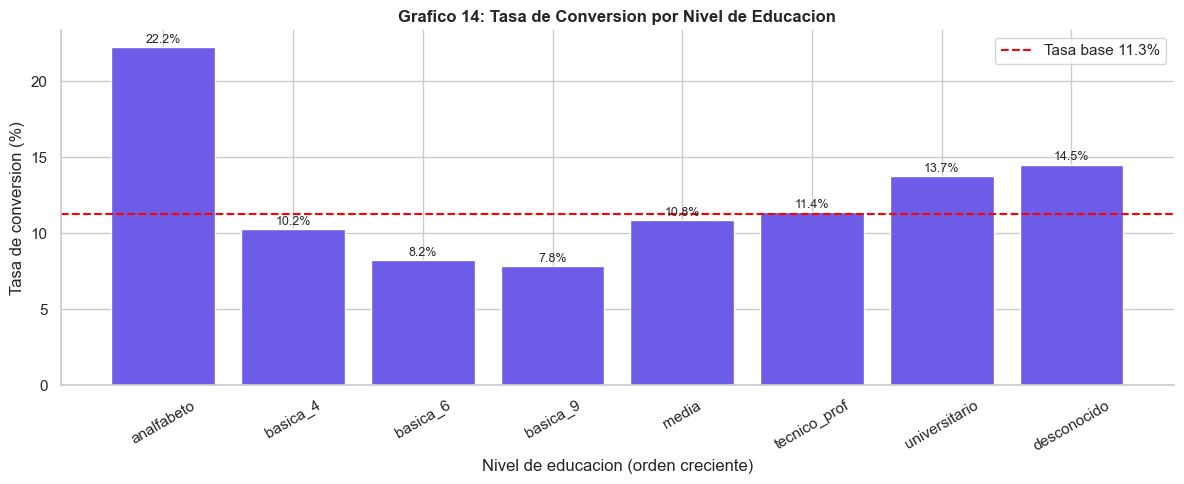

In [16]:
orden_edu = ['analfabeto','basica_4','basica_6','basica_9','media','tecnico_prof','universitario','desconocido']
edu_conv = df.groupby('educacion')['deposito_plazo_num'].mean()*100
edu_conv = edu_conv.reindex(orden_edu).dropna()
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(edu_conv.index, edu_conv.values, color='#6c5ce7', edgecolor='white')
for bar, val in zip(bars, edu_conv.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            str(round(val,1))+'%', ha='center', fontsize=9)
tasa_base = df['deposito_plazo_num'].mean()*100
ax.axhline(tasa_base, color='red', linestyle='--', label='Tasa base '+str(round(tasa_base,1))+'%')
ax.set_xlabel('Nivel de educacion (orden creciente)')
ax.set_ylabel('Tasa de conversion (%)')
ax.set_title('Grafico 14: Tasa de Conversion por Nivel de Educacion', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('graficos/bivariado_educacion_conversion.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 15: Canal de Contacto vs Conversion (Relativa vs Absoluta)

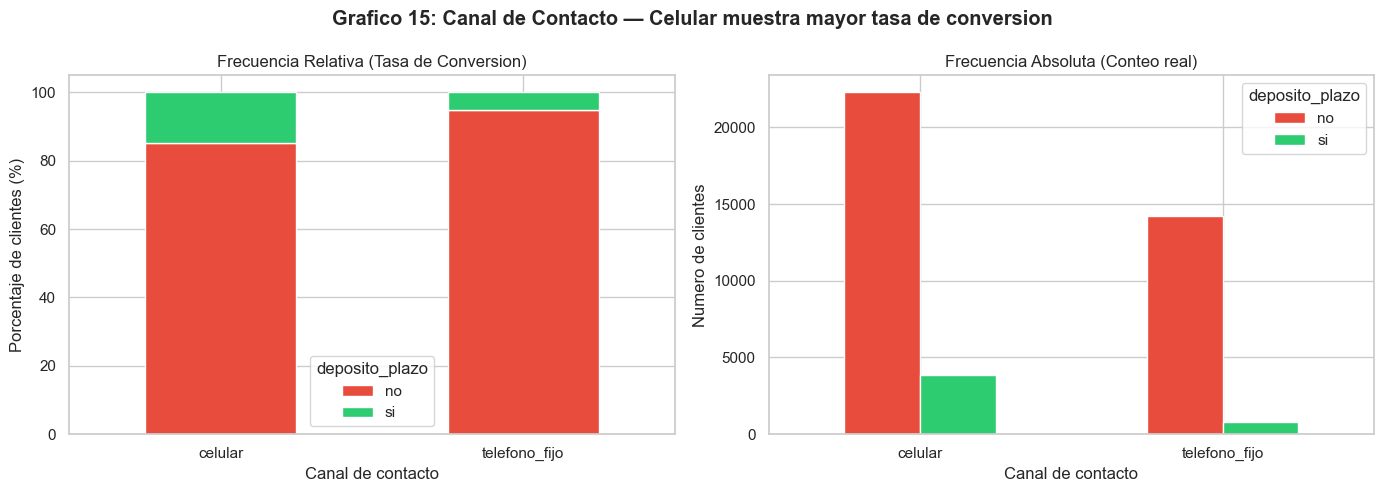

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
contact_rel = pd.crosstab(df['contacto'], df['deposito_plazo'], normalize='index')*100
contact_rel.plot(kind='bar', stacked=True, color=['#e74c3c','#2ecc71'], ax=axes[0], edgecolor='white')
axes[0].set_xlabel('Canal de contacto')
axes[0].set_ylabel('Porcentaje de clientes (%)')
axes[0].set_title('Frecuencia Relativa (Tasa de Conversion)')
axes[0].tick_params(axis='x', rotation=0)
contact_abs = pd.crosstab(df['contacto'], df['deposito_plazo'])
contact_abs.plot(kind='bar', color=['#e74c3c','#2ecc71'], ax=axes[1], edgecolor='white')
axes[1].set_xlabel('Canal de contacto')
axes[1].set_ylabel('Numero de clientes')
axes[1].set_title('Frecuencia Absoluta (Conteo real)')
axes[1].tick_params(axis='x', rotation=0)
plt.suptitle('Grafico 15: Canal de Contacto — Celular muestra mayor tasa de conversion', fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/bivariado_contacto_conversion.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 16: Resultado Campana Anterior vs Conversion

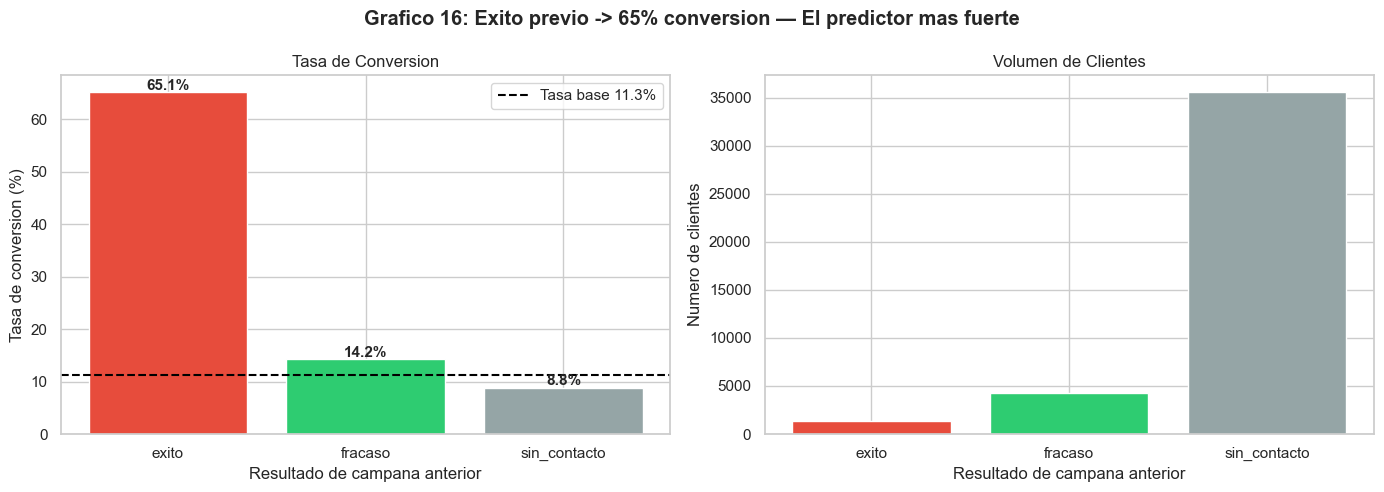

In [18]:
ra_conv = df.groupby('resultado_anterior')['deposito_plazo_num'].mean()*100
ra_count = df.groupby('resultado_anterior')['deposito_plazo_num'].count()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores_ra = ['#e74c3c','#2ecc71','#95a5a6']
axes[0].bar(ra_conv.index, ra_conv.values, color=colores_ra, edgecolor='white')
for i, val in enumerate(ra_conv.values):
    axes[0].text(i, val+0.5, str(round(val,1))+'%', ha='center', fontweight='bold', fontsize=11)
tasa_base = df['deposito_plazo_num'].mean()*100
axes[0].axhline(tasa_base, color='black', linestyle='--',
                label='Tasa base '+str(round(tasa_base,1))+'%')
axes[0].set_xlabel('Resultado de campana anterior')
axes[0].set_ylabel('Tasa de conversion (%)')
axes[0].set_title('Tasa de Conversion')
axes[0].legend()
axes[1].bar(ra_count.index, ra_count.values, color=colores_ra, edgecolor='white')
axes[1].set_xlabel('Resultado de campana anterior')
axes[1].set_ylabel('Numero de clientes')
axes[1].set_title('Volumen de Clientes')
plt.suptitle('Grafico 16: Exito previo -> 65% conversion — El predictor mas fuerte', fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/bivariado_resultado_anterior_conversion.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 17: Mes de Contacto vs Conversion (Volumen vs Tasa)

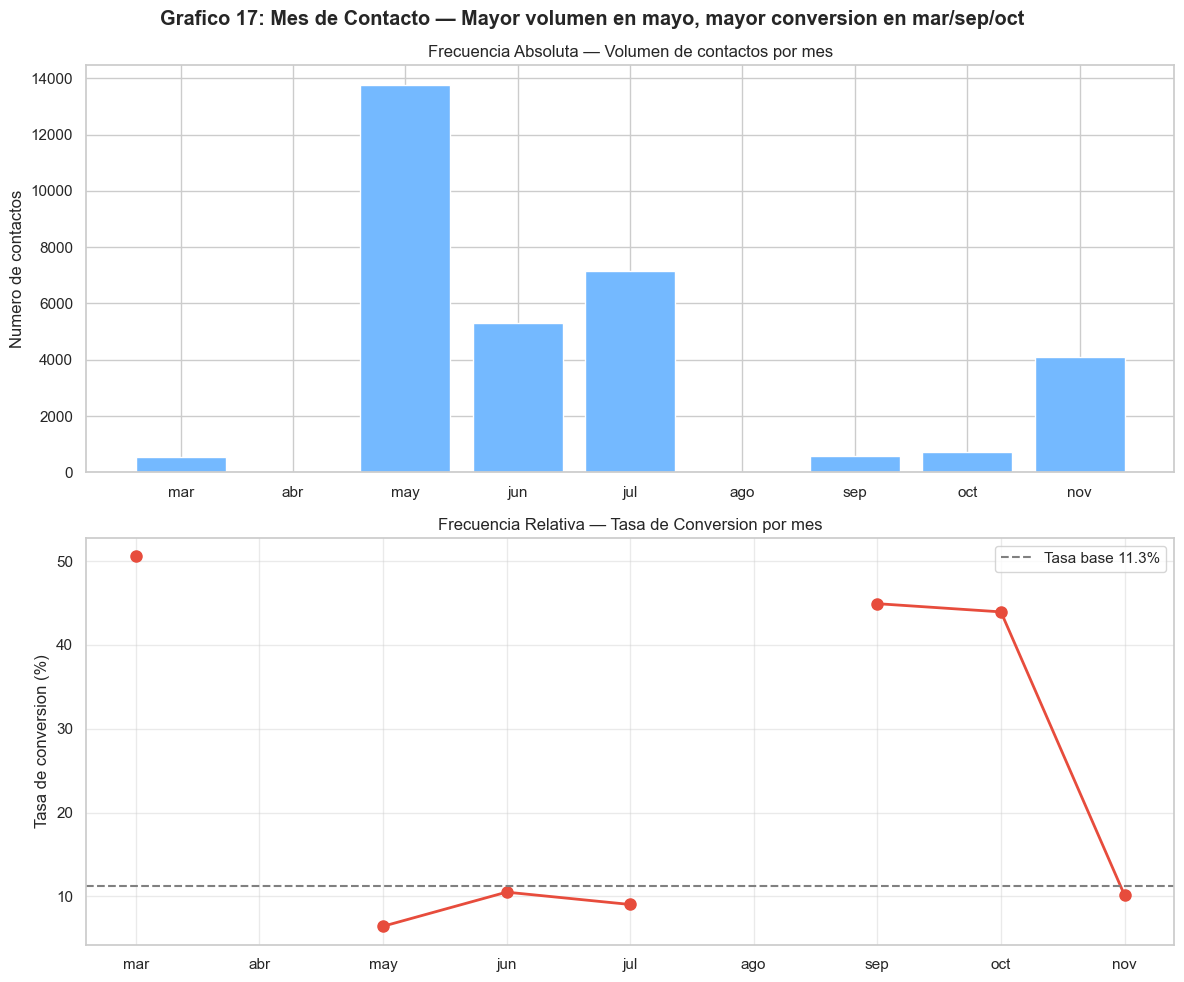

In [19]:
order_months = ['mar','abr','may','jun','jul','ago','sep','oct','nov','dic']
conv_mes = df.groupby('mes')['deposito_plazo_num'].mean().reindex(order_months)*100
vol_mes = df.groupby('mes')['deposito_plazo_num'].count().reindex(order_months)
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
axes[0].bar(vol_mes.index, vol_mes.values, color='#74b9ff', edgecolor='white')
axes[0].set_ylabel('Numero de contactos')
axes[0].set_title('Frecuencia Absoluta — Volumen de contactos por mes')
axes[1].plot(conv_mes.index, conv_mes.values, marker='o', color='#e74c3c', linewidth=2, markersize=8)
tasa_base = df['deposito_plazo_num'].mean()*100
axes[1].axhline(tasa_base, color='gray', linestyle='--', label='Tasa base '+str(round(tasa_base,1))+'%')
axes[1].set_ylabel('Tasa de conversion (%)')
axes[1].set_title('Frecuencia Relativa — Tasa de Conversion por mes')
axes[1].legend()
axes[1].grid(True, alpha=0.4)
plt.suptitle('Grafico 17: Mes de Contacto — Mayor volumen en mayo, mayor conversion en mar/sep/oct', fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/bivariado_mes_conversion.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 18: Tasa Euribor vs Conversion

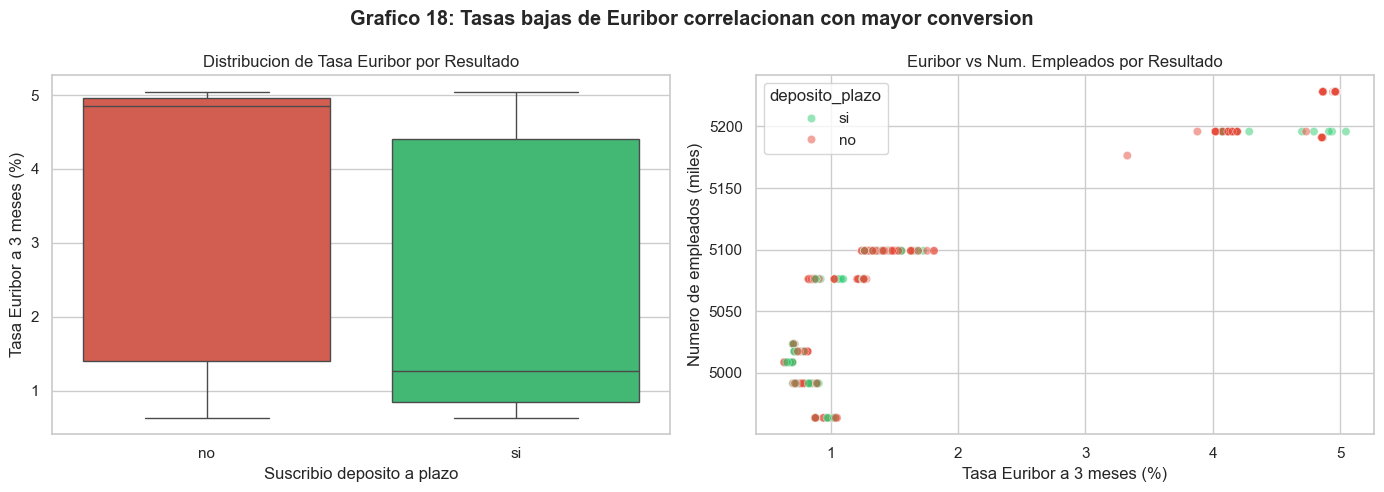

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette_dep = {'si':'#2ecc71','no':'#e74c3c'}
sns.boxplot(data=df, x='deposito_plazo', y='tasa_euribor', palette=palette_dep, ax=axes[0])
axes[0].set_xlabel('Suscribio deposito a plazo')
axes[0].set_ylabel('Tasa Euribor a 3 meses (%)')
axes[0].set_title('Distribucion de Tasa Euribor por Resultado')
sns.scatterplot(data=df.sample(3000, random_state=42), x='tasa_euribor', y='num_empleados',
                hue='deposito_plazo', palette=palette_dep, alpha=0.5, ax=axes[1])
axes[1].set_xlabel('Tasa Euribor a 3 meses (%)')
axes[1].set_ylabel('Numero de empleados (miles)')
axes[1].set_title('Euribor vs Num. Empleados por Resultado')
plt.suptitle('Grafico 18: Tasas bajas de Euribor correlacionan con mayor conversion', fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/bivariado_tasa_euribor_conversion.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 19: Numero de Contactos en Campana vs Conversion

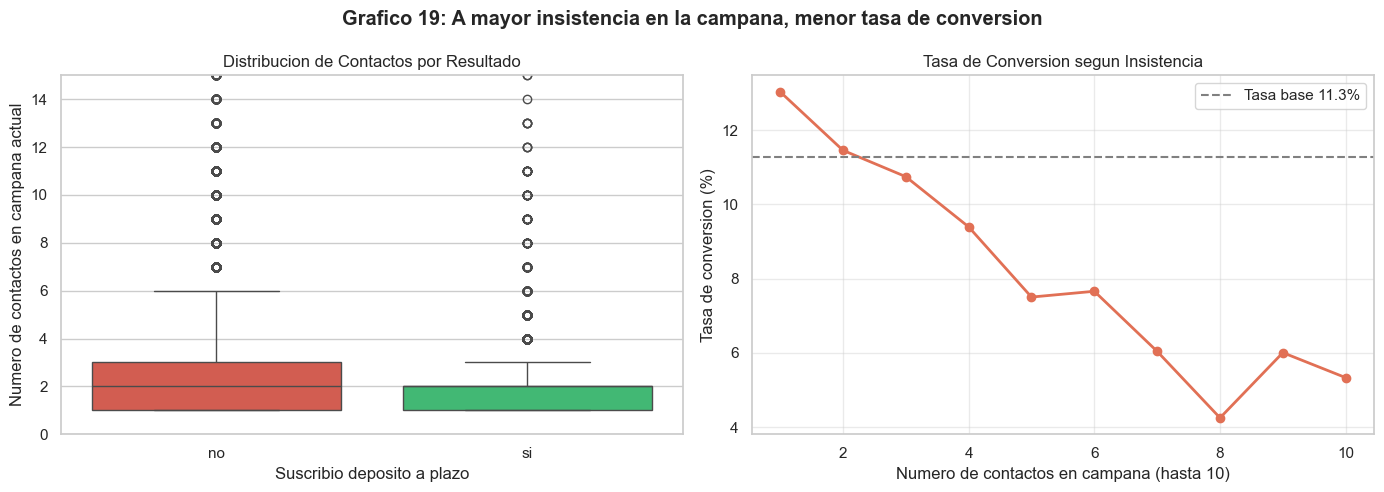

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette_dep = {'si':'#2ecc71','no':'#e74c3c'}
sns.boxplot(data=df, x='deposito_plazo', y='campana', palette=palette_dep, ax=axes[0])
axes[0].set_ylim(0, 15)
axes[0].set_xlabel('Suscribio deposito a plazo')
axes[0].set_ylabel('Numero de contactos en campana actual')
axes[0].set_title('Distribucion de Contactos por Resultado')
conv_campana = df[df['campana']<=10].groupby('campana')['deposito_plazo_num'].mean()*100
axes[1].plot(conv_campana.index, conv_campana.values, marker='o', color='#e17055', linewidth=2)
tasa_base = df['deposito_plazo_num'].mean()*100
axes[1].axhline(tasa_base, color='gray', linestyle='--', label='Tasa base '+str(round(tasa_base,1))+'%')
axes[1].set_xlabel('Numero de contactos en campana (hasta 10)')
axes[1].set_ylabel('Tasa de conversion (%)')
axes[1].set_title('Tasa de Conversion segun Insistencia')
axes[1].legend()
axes[1].grid(True, alpha=0.4)
plt.suptitle('Grafico 19: A mayor insistencia en la campana, menor tasa de conversion', fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/bivariado_campana_conversion.png', bbox_inches='tight', dpi=150)
plt.show()

### Grafico 20: Historial Previo de Contacto vs Conversion

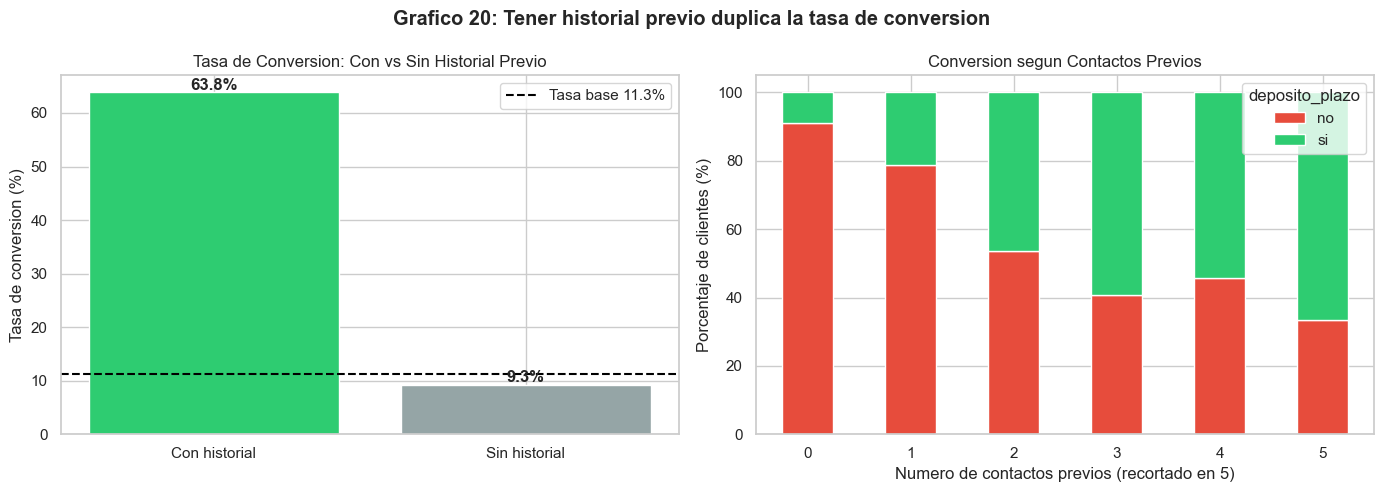

In [22]:
df['fue_contactado'] = (df['dias_previos']!=999).map({True:'Con historial',False:'Sin historial'})
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
conv_hist = df.groupby('fue_contactado')['deposito_plazo_num'].mean()*100
colores_hist = ['#2ecc71','#95a5a6']
bars = axes[0].bar(conv_hist.index, conv_hist.values, color=colores_hist, edgecolor='white')
for bar, val in zip(bars, conv_hist.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 str(round(val,1))+'%', ha='center', fontweight='bold', fontsize=12)
tasa_base = df['deposito_plazo_num'].mean()*100
axes[0].axhline(tasa_base, color='black', linestyle='--', label='Tasa base '+str(round(tasa_base,1))+'%')
axes[0].set_ylabel('Tasa de conversion (%)')
axes[0].set_title('Tasa de Conversion: Con vs Sin Historial Previo')
axes[0].legend()
prev_res = pd.crosstab(df['anterior'].clip(0,5), df['deposito_plazo'], normalize='index')*100
prev_res.plot(kind='bar', stacked=True, color=['#e74c3c','#2ecc71'], ax=axes[1], edgecolor='white')
axes[1].set_xlabel('Numero de contactos previos (recortado en 5)')
axes[1].set_ylabel('Porcentaje de clientes (%)')
axes[1].set_title('Conversion segun Contactos Previos')
axes[1].tick_params(axis='x', rotation=0)
plt.suptitle('Grafico 20: Tener historial previo duplica la tasa de conversion', fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/bivariado_historial_previo_conversion.png', bbox_inches='tight', dpi=150)
plt.show()

## 3. Analisis Multivariado

Relaciones entre multiples variables: multicolinealidad entre predictores y correlacion conjunta con la variable objetivo.

### Grafico 21: Matriz de Correlacion Spearman — Variables Numericas

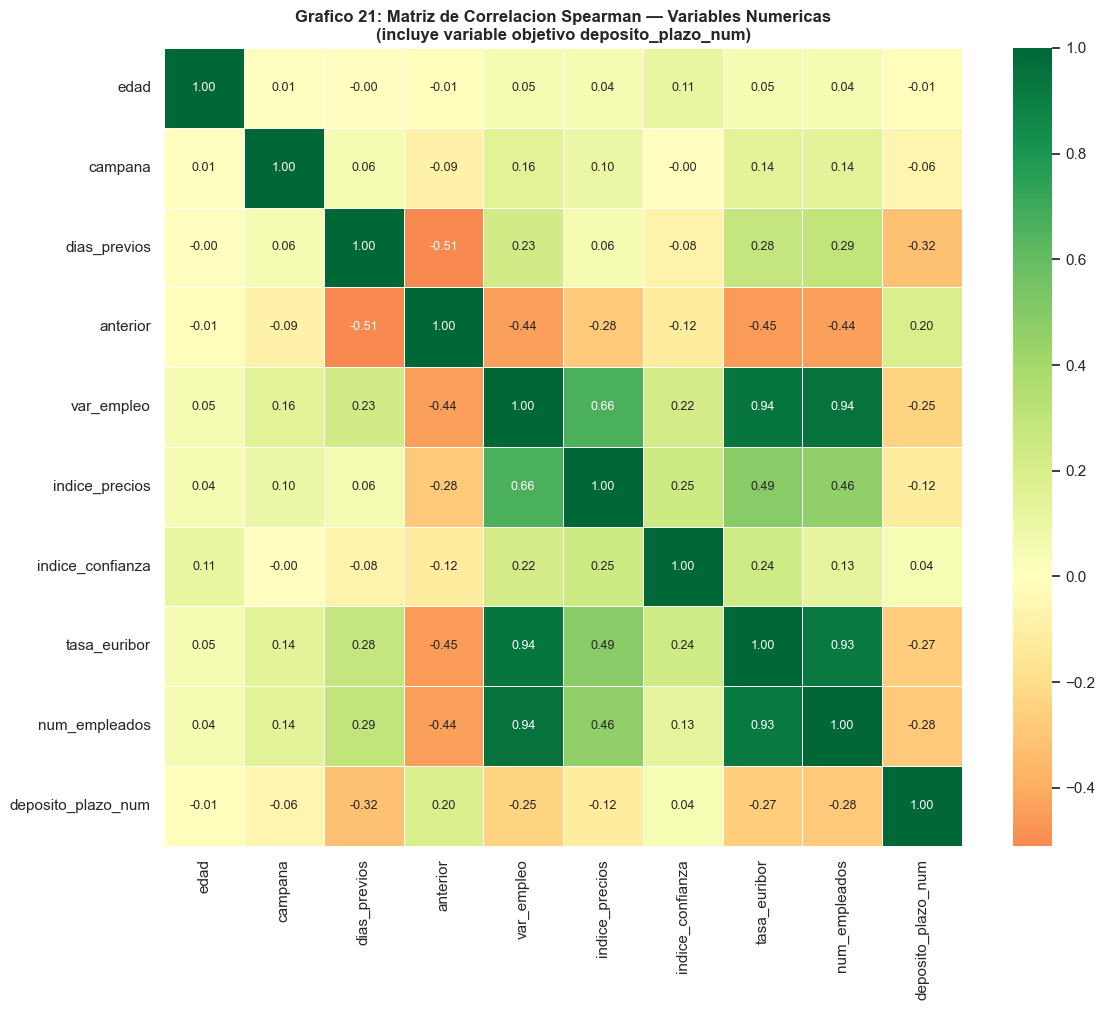

Nota: Las variables macroeconomicas muestran alta multicolinealidad entre si.


In [23]:
num_cols_corr = ['edad','campana','dias_previos','anterior',
                 'var_empleo','indice_precios','indice_confianza','tasa_euribor',
                 'num_empleados','deposito_plazo_num']
corr_matrix = df[num_cols_corr].corr(method='spearman')
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=ax, linewidths=0.5, annot_kws={'size':9}, square=True)
ax.set_title('Grafico 21: Matriz de Correlacion Spearman — Variables Numericas\n'
             '(incluye variable objetivo deposito_plazo_num)', fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/multivariado_correlacion_spearman.png', bbox_inches='tight', dpi=150)
plt.show()
print('Nota: Las variables macroeconomicas muestran alta multicolinealidad entre si.')

### Grafico 22: Multicolinealidad — Variables Macroeconomicas

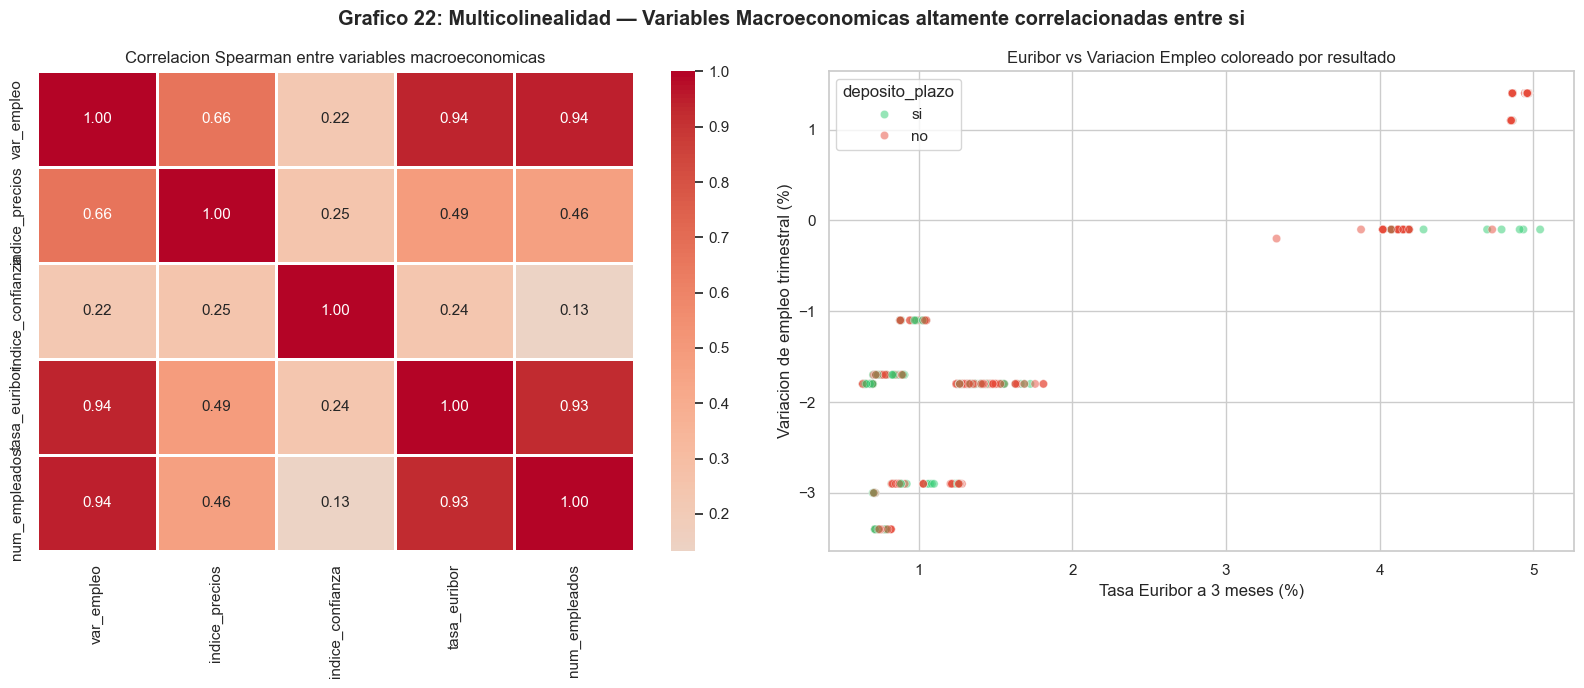

In [24]:
macro = ['var_empleo','indice_precios','indice_confianza','tasa_euribor','num_empleados']
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.heatmap(df[macro].corr(method='spearman'), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[0], linewidths=1, annot_kws={'size':11})
axes[0].set_title('Correlacion Spearman entre variables macroeconomicas')
sns.scatterplot(data=df.sample(3000, random_state=42), x='tasa_euribor', y='var_empleo',
                hue='deposito_plazo', palette={'si':'#2ecc71','no':'#e74c3c'},
                alpha=0.5, ax=axes[1])
axes[1].set_xlabel('Tasa Euribor a 3 meses (%)')
axes[1].set_ylabel('Variacion de empleo trimestral (%)')
axes[1].set_title('Euribor vs Variacion Empleo coloreado por resultado')
plt.suptitle('Grafico 22: Multicolinealidad — Variables Macroeconomicas altamente correlacionadas entre si', fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/multivariado_multicolinealidad_macroeconomica.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. Pipeline de Preprocesamiento para Machine Learning

Preparacion del dataset para un hipotetico modelo de clasificacion. Se documentan los pasos sin entrenar modelos.

In [25]:
from sklearn.preprocessing import StandardScaler

print('Pipeline de Preprocesamiento para Machine Learning')
print('='*55)
df_ml = df.copy()

# Paso 1: Imputacion de valores desconocidos por moda
cols_unknown = ['trabajo','estado_civil','educacion','mora','vivienda','prestamo']
for col in cols_unknown:
    if 'desconocido' in df_ml[col].values:
        moda = df_ml[df_ml[col]!='desconocido'][col].mode()[0]
        n = (df_ml[col]=='desconocido').sum()
        df_ml[col] = df_ml[col].replace('desconocido', moda)
        print(f'Paso 1 - {col}: {n} valores imputados con moda = {moda}')

# Paso 2: Capping de outliers con IQR
def cap_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return series.clip(lower=Q1-1.5*IQR, upper=Q3+1.5*IQR)
df_ml['edad'] = cap_outliers(df_ml['edad'])
df_ml['campana'] = cap_outliers(df_ml['campana'])
print('Paso 2 - Outliers capeados en edad y campana usando IQR')

# Paso 3: One-Hot Encoding para variables categoricas
cat_cols_ml = df_ml.select_dtypes(include=['object']).columns.drop('deposito_plazo').tolist()
n_antes = df_ml.shape[1]
df_ml = pd.get_dummies(df_ml, columns=cat_cols_ml, drop_first=True)
bool_cols = df_ml.select_dtypes(include=['bool']).columns
df_ml[bool_cols] = df_ml[bool_cols].astype(int)
print(f'Paso 3 - OHE: {n_antes} -> {df_ml.shape[1]} columnas')

# Paso 4: StandardScaler para variables numericas
num_cols_ml = ['edad','campana','dias_previos','anterior',
               'var_empleo','indice_precios','indice_confianza','tasa_euribor','num_empleados']
scaler = StandardScaler()
df_ml[num_cols_ml] = scaler.fit_transform(df_ml[num_cols_ml])
print('Paso 4 - StandardScaler aplicado a variables numericas (media=0, std=1)')

print()
print(f'Dataset listo para ML: {df_ml.shape[0]:,} filas x {df_ml.shape[1]} columnas')
print(f'Variable objetivo: deposito_plazo_num (1=si, 0=no)')
print(f"Desbalanceo: {df_ml['deposito_plazo_num'].value_counts().to_dict()}")

Pipeline de Preprocesamiento para Machine Learning
Paso 1 - trabajo: 330 valores imputados con moda = administrativo
Paso 1 - estado_civil: 80 valores imputados con moda = casado
Paso 1 - educacion: 1730 valores imputados con moda = universitario
Paso 1 - mora: 8596 valores imputados con moda = no
Paso 1 - vivienda: 990 valores imputados con moda = si
Paso 1 - prestamo: 990 valores imputados con moda = no
Paso 2 - Outliers capeados en edad y campana usando IQR
Paso 3 - OHE: 23 -> 50 columnas
Paso 4 - StandardScaler aplicado a variables numericas (media=0, std=1)

Dataset listo para ML: 41,176 filas x 50 columnas
Variable objetivo: deposito_plazo_num (1=si, 0=no)
Desbalanceo: {0: 36537, 1: 4639}


### Modelos a Implementar (hipotetico)

El problema es de **clasificacion binaria** (deposito_plazo = si/no).

| Modelo | Justificacion |
|---|---|
| Regresion Logistica | Baseline interpretable; coeficientes muestran direccion e importancia |
| Random Forest | Robusto a outliers, captura interacciones no lineales |
| XGBoost | Estado del arte en clasificacion tabular con clases desbalanceadas |

**Metodologia de validacion:** Stratified K-Fold (k=5) para respetar la proporcion 90/10% en cada fold.  
**Metricas:** ROC-AUC (principal), Precision, Recall, F1-Score.

## 5. Conclusiones

### Es posible crear un modelo predictivo?
Si. Las variables muestran correlaciones significativas con la variable objetivo. Las mas relevantes son: `tasa_euribor`, `num_empleados`, `resultado_anterior`, `dias_previos`, `var_empleo`.

### Que caracteriza a un cliente que contrata un deposito a plazo?
- **Exito en campana anterior:** Conversion del 65% vs 11% de la tasa base.
- **Contexto economico favorable:** Tasas Euribor bajas (< 2%) coinciden con mayor conversion.
- **Con historial de contacto:** Clientes contactados previamente tienen doble de probabilidad.
- **Perfil demografico:** Jubilados y estudiantes muestran las mayores tasas de conversion.
- **Insistencia contraproducente:** Mas contactos en la campana actual = menor conversion.

### Variables descartadas
- `duration` (duracion de la llamada): eliminada por ser **data leaker** — solo se conoce al final de la llamada, no puede usarse para predecir.

### Contexto economico
Las variables macroeconomicas son los predictores mas fuertes pero presentan **alta multicolinealidad**. En un modelo real se recomienda retener solo `tasa_euribor` o aplicar PCA sobre el grupo macroeconomico.